In [194]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [195]:
df = pd.read_csv("CustomerData.csv")
df


,CustomerID,Age,Gender,City,AnnualIncome,TotalSpent,MonthlyPurchases,AvgOrderValue,AppTimeMinutes,DiscountUsage,PreferredShoppingTime
0,C001,28,F,Bangalore,450000.0,120000,6,2000,45.0,Medium,Night
1,C002,35,M,Mumbai,1200000.0,850000,18,12000,120.0,Low,Night
2,C003,42,F,Delhi,300000.0,75000,3,1800,30.0,High,Day
3,C004,26,M,Pune,NaN,40000,2,1500,20.0,High,Day
4,C005,39,F,Bangalore,950000.0,600000,15,9000,95.0,Low,Night
...,...,...,...,...,...,...,...,...,...,...,...
95,C096,32,M,Kolkata,520000.0,210000,8,2800,64.0,Medium,Day
96,C097,55,M,Bangalore,1400000.0,980000,20,14500,150.0,Low,Night
97,C098,37,F,Pune,590000.0,260000,9,3100,69.0,Medium,Day
98,C099,24,M,Delhi,200000.0,30000,1,1200,10.0,High,Day


In [196]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "Gender",
    "City",
    "DiscountUsage",
    "PreferredShoppingTime"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [197]:
outlier_cols = [
    "AnnualIncome",
    "TotalSpent",
    "MonthlyPurchases",
    "AvgOrderValue",
    "AppTimeMinutes"
]
 
Q1 = df[outlier_cols].quantile(0.25)
Q3 = df[outlier_cols].quantile(0.75)
IQR = Q3 - Q1
 
outliers = ((df[outlier_cols] < (Q1 - 1.5 * IQR)) |
            (df[outlier_cols] > (Q3 + 1.5 * IQR)))
df_clean = df[~outliers. any(axis=1)]

In [198]:
numeric_cols = [
    "Age", "AnnualIncome", "TotalSpent", 
    "MonthlyPurchases", "AvgOrderValue", "AppTimeMinutes", "DiscountUsage"
]

X = df_clean[numeric_cols]  # use df_clean after removing outliers
X = X.fillna(X.median())

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3000\1576515178.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Cluster"] = kmeans.fit_predict(X_scaled)


In [199]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3000\1053032538.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Cluster"] = kmeans.fit_predict(X_scaled)


In [201]:
cluster_labels = {
    0: "High-Value Loyal Customers",
    1: "Value-Seeking Regular Customers",
    2: "Price-Sensitive Occasional Customers"
}

df_clean["Customer Segment"] = df_clean["Cluster"].map(cluster_labels)


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3000\3993346306.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Customer Segment"] = df_clean["Cluster"].map(cluster_labels)


In [202]:
offers = {
    "High-Value Loyal Customers": 
        "Exclusive early access to new products + Premium membership with free express delivery",

    "Value-Seeking Regular Customers": 
        "Festival discounts (10–15%) + Loyalty reward points",

    "Price-Sensitive Occasional Customers": 
        "Flash sales, coupons, and free shipping on minimum order"
}

df_clean["Recommended Offer"] = df_clean["Customer Segment"].map(offers)


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3000\2386998885.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Recommended Offer"] = df_clean["Customer Segment"].map(offers)


In [203]:
df_final = df_clean[
    ["Customer Segment", "Recommended Offer"]
]

print(df_final.head())


                       Customer Segment  \
0            High-Value Loyal Customers   
1       Value-Seeking Regular Customers   
2  Price-Sensitive Occasional Customers   
3  Price-Sensitive Occasional Customers   
4       Value-Seeking Regular Customers   

                                   Recommended Offer  
0  Exclusive early access to new products + Premi...  
1  Festival discounts (10–15%) + Loyalty reward p...  
2  Flash sales, coupons, and free shipping on min...  
3  Flash sales, coupons, and free shipping on min...  
4  Festival discounts (10–15%) + Loyalty reward p...  


In [ ]:

cluster_counts = df_clean['Cluster'].value_counts()
largest_cluster = cluster_counts.idxmax()
mapping = {largest_cluster: 1}
remaining_clusters = [c for c in cluster_counts.index if c != largest_cluster]
mapping[remaining_clusters[0]] = 0
mapping[remaining_clusters[1]] = 2
df_clean['Cluster'] = df_clean['Cluster'].map(mapping)


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3000\2772229526.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = df_clean['Cluster'].map(mapping)


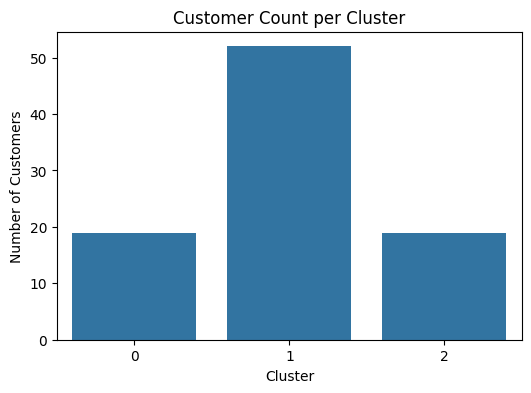

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Cluster", data=df_clean)
plt.title("Customer Count per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


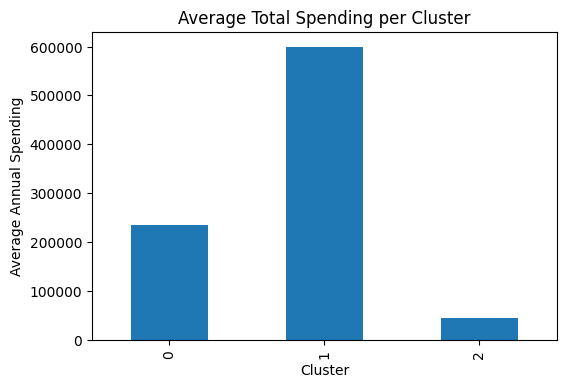

In [205]:
avg_spending = df_clean.groupby("Cluster")["TotalSpent"].median()

plt.figure(figsize=(6,4))
avg_spending.plot(kind="bar")
plt.title("Average Total Spending per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Annual Spending")
plt.show()


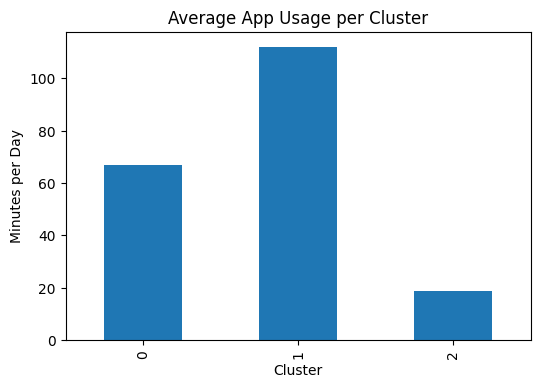

In [206]:
avg_app_usage = df_clean.groupby("Cluster")[
    "AppTimeMinutes"
].mean()

plt.figure(figsize=(6,4))
avg_app_usage.plot(kind="bar")
plt.title("Average App Usage per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Minutes per Day")
plt.show()


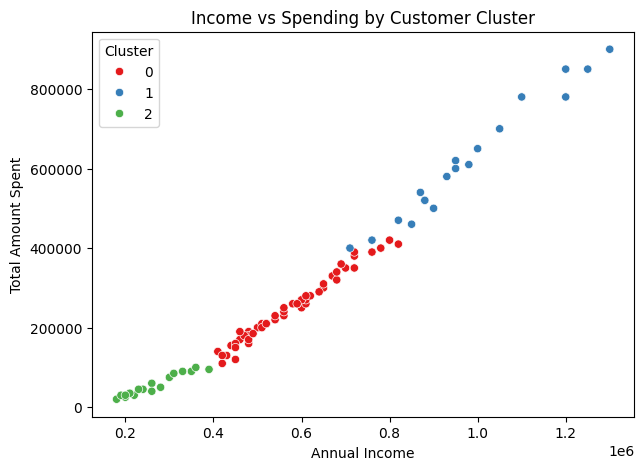

In [207]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="AnnualIncome",
    y="TotalSpent",
    hue="Cluster",
    data=df_clean,
    palette="Set1"
)

plt.title("Income vs Spending by Customer Cluster")
plt.xlabel("Annual Income")
plt.ylabel("Total Amount Spent")
plt.show()


In [208]:
import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)


In [209]:
df_clean["Offer Given"] = df_clean["Cluster"].map(offers)
df_clean["Customer Segment"] = df_clean["Cluster"].map(cluster_labels)

df_clean.to_csv("customer_data_with_offers.csv", index=False)


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3000\57901052.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Offer Given"] = df_clean["Cluster"].map(offers)
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3000\57901052.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Customer Segment"] = df_clean["Cluster"].map(cluster_labels)
